In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.preprocessing import LabelEncoder
from scipy.stats import ttest_rel
import shap

import warnings
warnings.filterwarnings("ignore")

c:\Users\Hp\OneDrive\Desktop\hydrology_crop_decision_support\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
np.random.seed(42)

In [4]:
df = pd.read_csv("../processed_data/crop_model_dataset.csv")

df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   nitrogen     20000 non-null  float64
 1   phosphorus   20000 non-null  float64
 2   potassium    20000 non-null  float64
 3   temperature  20000 non-null  float64
 4   humidity     20000 non-null  float64
 5   ph           20000 non-null  float64
 6   rainfall     20000 non-null  float64
 7   crop         20000 non-null  object 
 8   soil_type    20000 non-null  object 
dtypes: float64(7), object(2)
memory usage: 1.4+ MB


,nitrogen,phosphorus,potassium,temperature,humidity,ph,rainfall
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,77.216965,47.482070,55.162956,27.420717,64.897753,6.496126,211.124002
std,41.857663,24.587506,25.969091,10.010144,20.200687,1.155750,109.724973
min,5.006013,5.000483,10.000672,10.003760,30.002297,4.500082,20.018991
25%,40.459715,26.225044,32.641905,18.880888,47.462026,5.497988,117.208556
50%,77.573159,47.469579,55.248133,27.366450,64.776613,6.493812,211.263577
75%,113.055595,68.625556,77.690183,35.997484,82.310482,7.501771,305.668849
max,149.998785,89.999086,99.996480,44.997407,99.992346,8.499914,399.974915


In [5]:
df.isnull().sum()

nitrogen       0
phosphorus     0
potassium      0
temperature    0
humidity       0
ph             0
rainfall       0
crop           0
soil_type      0
dtype: int64

In [6]:
df= df.dropna()

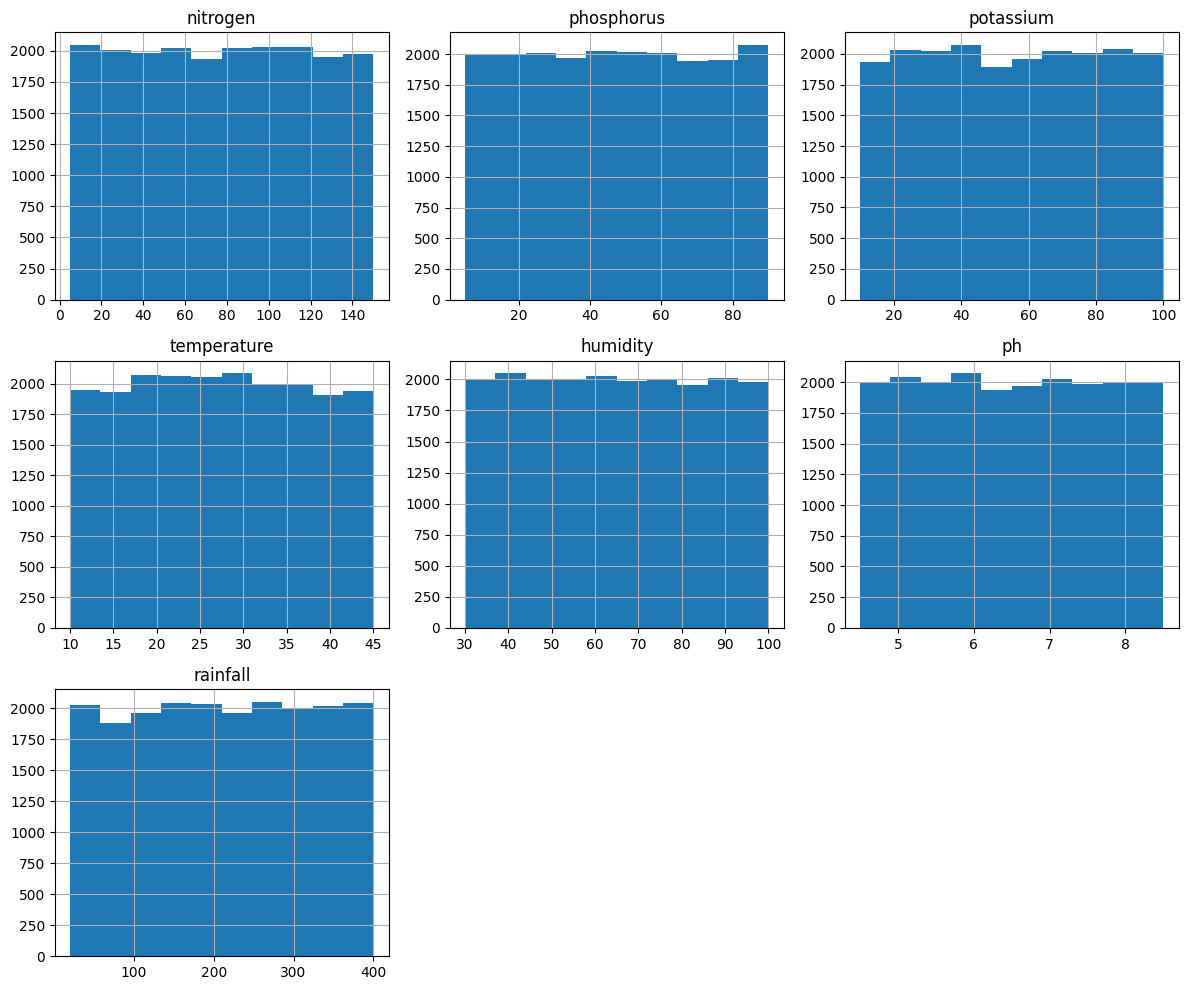

In [7]:
df.hist(figsize=(12,10))
plt.tight_layout()
plt.show()

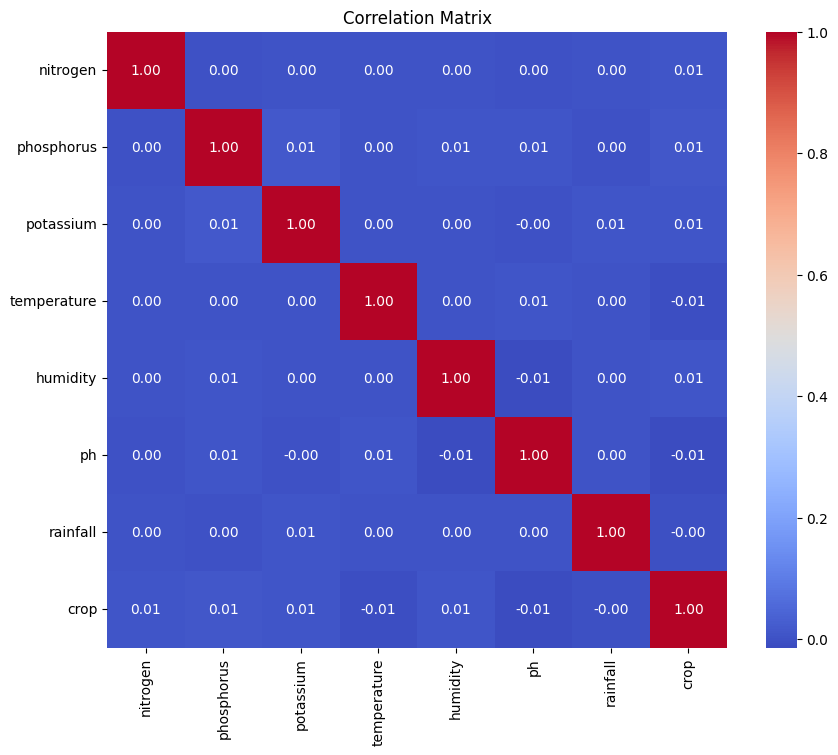

In [14]:
plt.figure(figsize=(10,8))

corr_matrix = df.corr(numeric_only=True)

sns.heatmap(corr_matrix, 
            annot=True, 
            cmap="coolwarm", 
            fmt=".2f")

plt.title("Correlation Matrix")
plt.show()

In [11]:
le = LabelEncoder()
df["crop"] = le.fit_transform(df["crop"])

In [12]:
X = df.drop("crop", axis=1)
y = df["crop"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [15]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

categorical_cols = X.select_dtypes(include=["object"]).columns
numeric_cols = X.select_dtypes(exclude=["object"]).columns

preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

rf_pipeline = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", RandomForestClassifier(random_state=42))
])

rf_pipeline.fit(X_train, y_train)

,steps,"[('preprocess', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


Dataset Shape: (20000, 9)

Columns:
 Index(['nitrogen', 'phosphorus', 'potassium', 'temperature', 'humidity', 'ph',
       'rainfall', 'crop', 'soil_type'],
      dtype='object')

Missing Values:
 nitrogen       0
phosphorus     0
potassium      0
temperature    0
humidity       0
ph             0
rainfall       0
crop           0
soil_type      0
dtype: int64

Final Feature Shape After Encoding: (20000, 12)

===== MODEL RESULTS =====
           Model  Test Accuracy  CV Mean Accuracy
0  Random Forest        0.16025           0.16555
1            SVM        0.16000           0.17245
2        XGBoost        0.16625           0.16600

T-Test RF vs XGB
T-Statistic: -0.17915991796070171
P-Value: 0.8665211057709261


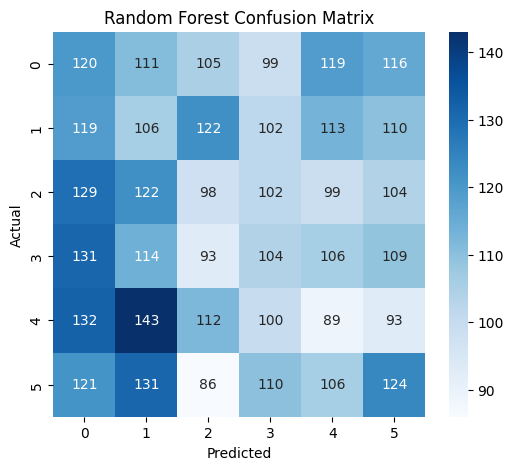

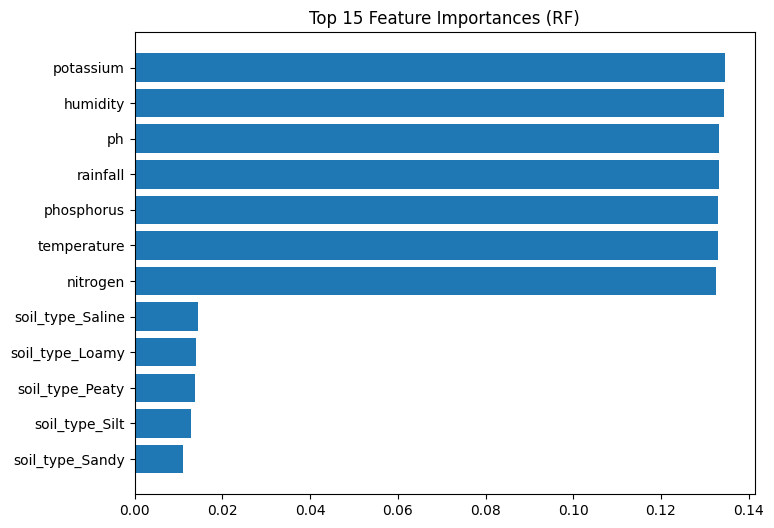

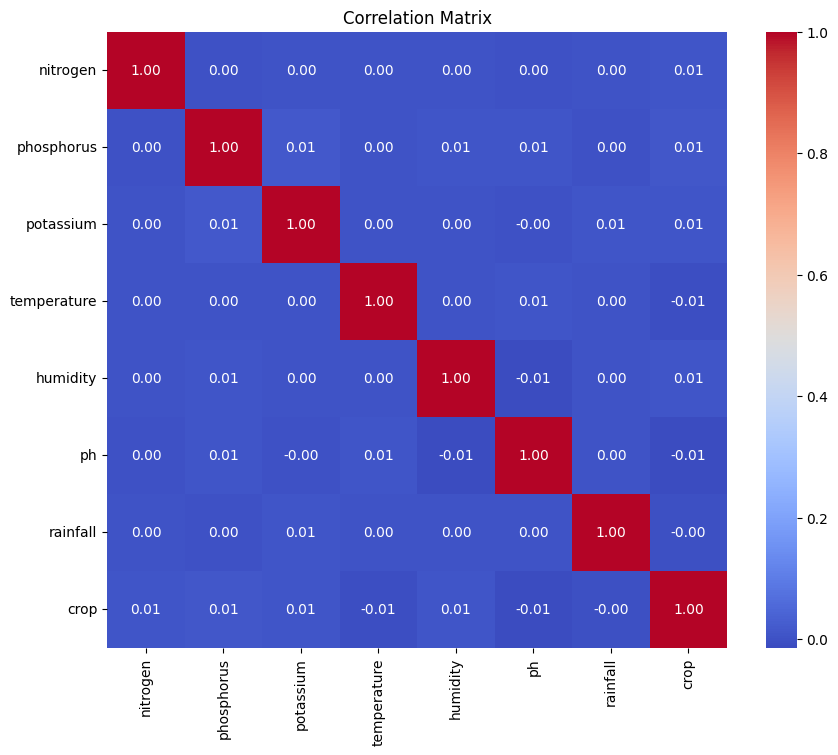


Notebook execution completed successfully.


In [17]:
# ==============================
# 1. IMPORTS
# ==============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from scipy.stats import ttest_rel

import warnings
warnings.filterwarnings("ignore")

np.random.seed(42)


# ==============================
# 2. LOAD DATA
# ==============================

df = pd.read_csv("../processed_data/crop_model_dataset.csv")

print("Dataset Shape:", df.shape)
print("\nColumns:\n", df.columns)
print("\nMissing Values:\n", df.isnull().sum())


# ==============================
# 3. CLEAN DATA
# ==============================

df = df.dropna()


# ==============================
# 4. ENCODE TARGET
# ==============================

le = LabelEncoder()
df["crop"] = le.fit_transform(df["crop"])


# ==============================
# 5. SPLIT FEATURES & TARGET
# ==============================

X = df.drop("crop", axis=1)
y = df["crop"]


# ==============================
# 6. ONE-HOT ENCODE CATEGORICAL FEATURES
# ==============================

X = pd.get_dummies(X, drop_first=True)

print("\nFinal Feature Shape After Encoding:", X.shape)


# ==============================
# 7. TRAIN TEST SPLIT
# ==============================

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)


# ==============================
# 8. MODEL TRAINING
# ==============================

# Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)

# SVM
svm = SVC()
svm.fit(X_train, y_train)
svm_pred = svm.predict(X_test)
svm_acc = accuracy_score(y_test, svm_pred)

# XGBoost
xgb = XGBClassifier(use_label_encoder=False, eval_metric="mlogloss")
xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)
xgb_acc = accuracy_score(y_test, xgb_pred)


# ==============================
# 9. CROSS VALIDATION
# ==============================

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_cv = cross_val_score(rf, X, y, cv=cv)
svm_cv = cross_val_score(svm, X, y, cv=cv)
xgb_cv = cross_val_score(xgb, X, y, cv=cv)


# ==============================
# 10. STATISTICAL SIGNIFICANCE TEST
# ==============================

t_stat, p_value = ttest_rel(rf_cv, xgb_cv)


# ==============================
# 11. RESULTS SUMMARY
# ==============================

results = pd.DataFrame({
    "Model": ["Random Forest", "SVM", "XGBoost"],
    "Test Accuracy": [rf_acc, svm_acc, xgb_acc],
    "CV Mean Accuracy": [rf_cv.mean(), svm_cv.mean(), xgb_cv.mean()]
})

print("\n===== MODEL RESULTS =====")
print(results)

print("\nT-Test RF vs XGB")
print("T-Statistic:", t_stat)
print("P-Value:", p_value)


# ==============================
# 12. CONFUSION MATRIX (RF)
# ==============================

plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_test, rf_pred), annot=True, fmt="d", cmap="Blues")
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# ==============================
# 13. FEATURE IMPORTANCE (RF)
# ==============================

importances = rf.feature_importances_
indices = np.argsort(importances)[-15:]  # top 15

plt.figure(figsize=(8,6))
plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), X.columns[indices])
plt.title("Top 15 Feature Importances (RF)")
plt.show()


# ==============================
# 14. CORRELATION MATRIX
# ==============================

plt.figure(figsize=(10,8))
corr_matrix = df.corr(numeric_only=True)
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()


print("\nNotebook execution completed successfully.")

In [18]:
print("Number of unique crops:", y.nunique())

Number of unique crops: 6


In [19]:
print(df["crop"].value_counts())

crop
5    3390
1    3362
0    3352
4    3344
3    3284
2    3268
Name: count, dtype: int64


In [20]:
print(sorted(rf.feature_importances_, reverse=True) [:5])

[np.float64(0.13461100565888107), np.float64(0.13426674992689866), np.float64(0.13321634110165848), np.float64(0.13314777901686847), np.float64(0.13305543588769164)]


In [21]:
df["np_ratio"] = df["nitrogen"] / (df["phosphorus"] + 1)
df["pk_ratio"] = df["phosphorus"] / (df["potassium"] + 1)
df["soil_health_index"] = (df["nitrogen"] + df["phosphorus"] + df["potassium"]) / 3

In [22]:
X = X.drop(columns=[col for col in X.columns if "state_" in col or "district_" in col])

In [23]:
rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

In [24]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [200, 500],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    n_jobs=-1
)

grid.fit(X, y)
print(grid.best_params_)

{'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 200}


In [25]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier()
gb.fit(X_train, y_train)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [26]:
# ==========================================
# 1. IMPORTS
# ==========================================

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

np.random.seed(42)


# ==========================================
# 2. LOAD DATA
# ==========================================

df = pd.read_csv("../processed_data/crop_model_dataset.csv")
df = df.dropna()

# Feature engineering
if all(col in df.columns for col in ["nitrogen", "phosphorus", "potassium"]):
    df["nutrient_index"] = (
        df["nitrogen"] + df["phosphorus"] + df["potassium"]
    ) / 3

# Encode target
le = LabelEncoder()
df["crop"] = le.fit_transform(df["crop"])

X = df.drop("crop", axis=1)
y = df["crop"]

# One-hot encode categorical
X = pd.get_dummies(X, drop_first=True)

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# ==========================================
# 3. TRAIN MODEL
# ==========================================

model = RandomForestClassifier(
    n_estimators=300,
    max_depth=20,
    min_samples_split=5,
    random_state=42
)

model.fit(X_train, y_train)


# ==========================================
# 4. TOP-K EVALUATION FUNCTIONS
# ==========================================

def top_k_accuracy(model, X_test, y_test, k=3):
    probs = model.predict_proba(X_test)
    top_k_preds = np.argsort(probs, axis=1)[:, -k:]

    correct = 0
    for i in range(len(y_test)):
        if y_test.iloc[i] in top_k_preds[i]:
            correct += 1

    return correct / len(y_test)


def mean_reciprocal_rank(model, X_test, y_test):
    probs = model.predict_proba(X_test)
    sorted_preds = np.argsort(probs, axis=1)[:, ::-1]

    mrr_total = 0

    for i in range(len(y_test)):
        true_label = y_test.iloc[i]
        rank = np.where(sorted_preds[i] == true_label)[0][0] + 1
        mrr_total += 1 / rank

    return mrr_total / len(y_test)


# ==========================================
# 5. EVALUATION
# ==========================================

top1 = top_k_accuracy(model, X_test, y_test, k=1)
top3 = top_k_accuracy(model, X_test, y_test, k=3)
top5 = top_k_accuracy(model, X_test, y_test, k=5)
mrr = mean_reciprocal_rank(model, X_test, y_test)

print("Top-1 Accuracy:", top1)
print("Top-3 Accuracy:", top3)
print("Top-5 Accuracy:", top5)
print("Mean Reciprocal Rank:", mrr)

Top-1 Accuracy: 0.168
Top-3 Accuracy: 0.4985
Top-5 Accuracy: 0.8275
Mean Reciprocal Rank: 0.40705416666667155


In [27]:
# ==========================================
# 1. IMPORTS
# ==========================================

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import SVC
from xgboost import XGBClassifier

np.random.seed(42)


# ==========================================
# 2. LOAD DATA
# ==========================================

df = pd.read_csv("../processed_data/crop_model_dataset.csv")
df = df.dropna()

# Feature Engineering
if all(col in df.columns for col in ["nitrogen", "phosphorus", "potassium"]):
    df["nutrient_index"] = (
        df["nitrogen"] + df["phosphorus"] + df["potassium"]
    ) / 3

# Encode Target
le = LabelEncoder()
df["crop"] = le.fit_transform(df["crop"])

X = df.drop("crop", axis=1)
y = df["crop"]

# One-hot encode categorical features
X = pd.get_dummies(X, drop_first=True)

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)


# ==========================================
# 3. TOP-K EVALUATION FUNCTIONS
# ==========================================

def top_k_accuracy(model, X_test, y_test, k=3):
    probs = model.predict_proba(X_test)
    top_k_preds = np.argsort(probs, axis=1)[:, -k:]

    correct = 0
    for i in range(len(y_test)):
        if y_test.iloc[i] in top_k_preds[i]:
            correct += 1

    return correct / len(y_test)


def mean_reciprocal_rank(model, X_test, y_test):
    probs = model.predict_proba(X_test)
    sorted_preds = np.argsort(probs, axis=1)[:, ::-1]

    mrr_total = 0

    for i in range(len(y_test)):
        true_label = y_test.iloc[i]
        rank = np.where(sorted_preds[i] == true_label)[0][0] + 1
        mrr_total += 1 / rank

    return mrr_total / len(y_test)


# ==========================================
# 4. XGBOOST TRAINING
# ==========================================

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    eval_metric="mlogloss",
    use_label_encoder=False,
    random_state=42
)

xgb.fit(X_train, y_train)

xgb_top1 = top_k_accuracy(xgb, X_test, y_test, k=1)
xgb_top3 = top_k_accuracy(xgb, X_test, y_test, k=3)
xgb_top5 = top_k_accuracy(xgb, X_test, y_test, k=5)
xgb_mrr = mean_reciprocal_rank(xgb, X_test, y_test)


# ==========================================
# 5. SVM TRAINING
# ==========================================

svm = SVC(
    kernel="rbf",
    C=10,
    gamma="scale",
    probability=True,   # Required for predict_proba
    random_state=42
)

svm.fit(X_train, y_train)

svm_top1 = top_k_accuracy(svm, X_test, y_test, k=1)
svm_top3 = top_k_accuracy(svm, X_test, y_test, k=3)
svm_top5 = top_k_accuracy(svm, X_test, y_test, k=5)
svm_mrr = mean_reciprocal_rank(svm, X_test, y_test)


# ==========================================
# 6. RESULTS
# ==========================================

results = pd.DataFrame({
    "Model": ["XGBoost", "SVM"],
    "Top-1": [xgb_top1, svm_top1],
    "Top-3": [xgb_top3, svm_top3],
    "Top-5": [xgb_top5, svm_top5],
    "MRR": [xgb_mrr, svm_mrr]
})

print("\n===== TOP-K RESULTS =====")
print(results)


===== TOP-K RESULTS =====
     Model   Top-1    Top-3    Top-5       MRR
0  XGBoost  0.1700  0.50150  0.83575  0.409488
1      SVM  0.1705  0.50075  0.83375  0.410617


Normalized Discounted Cumulative Gain

In [28]:
# ==========================================
# NDCG@K FUNCTION
# ==========================================

import numpy as np

def ndcg_at_k(model, X_test, y_test, k=5):
    probs = model.predict_proba(X_test)
    sorted_preds = np.argsort(probs, axis=1)[:, ::-1]  # descending order
    
    ndcg_total = 0
    
    for i in range(len(y_test)):
        true_label = y_test.iloc[i]
        top_k = sorted_preds[i][:k]
        
        if true_label in top_k:
            rank = np.where(top_k == true_label)[0][0] + 1
            dcg = 1 / np.log2(rank + 1)
        else:
            dcg = 0
        
        ndcg_total += dcg
    
    return ndcg_total / len(y_test)

In [33]:
# =====================================================
# 1. IMPORTS
# =====================================================

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

np.random.seed(42)


# =====================================================
# 2. LOAD DATA
# =====================================================

df = pd.read_csv("../processed_data/crop_model_dataset.csv")
df = df.dropna()

# Feature Engineering
if all(col in df.columns for col in ["nitrogen", "phosphorus", "potassium"]):
    df["nutrient_index"] = (
        df["nitrogen"] + df["phosphorus"] + df["potassium"]
    ) / 3

# Encode target
le = LabelEncoder()
df["crop"] = le.fit_transform(df["crop"])

X = df.drop("crop", axis=1)
y = df["crop"]

# One-hot encode categorical
X = pd.get_dummies(X, drop_first=True)

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# Align test columns
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)


# =====================================================
# 3. TRAIN MODELS
# =====================================================

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=20,
    min_samples_split=5,
    random_state=42
)
rf.fit(X_train, y_train)

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    eval_metric="mlogloss",
    use_label_encoder=False,
    random_state=42
)
xgb.fit(X_train, y_train)

svm = SVC(
    kernel="rbf",
    C=10,
    gamma="scale",
    probability=True,
    random_state=42
)
svm.fit(X_train, y_train)


# =====================================================
# 4. METRICS FUNCTIONS
# =====================================================

def top_k_accuracy(model, X_test, y_test, k=5):
    probs = model.predict_proba(X_test)
    top_k_preds = np.argsort(probs, axis=1)[:, -k:]
    
    correct = 0
    for i in range(len(y_test)):
        if y_test.iloc[i] in top_k_preds[i]:
            correct += 1
    
    return correct / len(y_test)


def mean_reciprocal_rank(model, X_test, y_test):
    probs = model.predict_proba(X_test)
    sorted_preds = np.argsort(probs, axis=1)[:, ::-1]
    
    mrr_total = 0
    for i in range(len(y_test)):
        true_label = y_test.iloc[i]
        rank = np.where(sorted_preds[i] == true_label)[0][0] + 1
        mrr_total += 1 / rank
    
    return mrr_total / len(y_test)


def ndcg_at_k(model, X_test, y_test, k=5):
    probs = model.predict_proba(X_test)
    sorted_preds = np.argsort(probs, axis=1)[:, ::-1]
    
    ndcg_total = 0
    for i in range(len(y_test)):
        true_label = y_test.iloc[i]
        top_k = sorted_preds[i][:k]
        
        if true_label in top_k:
            rank = np.where(top_k == true_label)[0][0] + 1
            dcg = 1 / np.log2(rank + 1)
        else:
            dcg = 0
        
        ndcg_total += dcg
    
    return ndcg_total / len(y_test)


# =====================================================
# 5. EVALUATION
# =====================================================

results = pd.DataFrame({
    "Model": ["RandomForest", "XGBoost", "SVM"],
    "Top-1": [
        top_k_accuracy(rf, X_test, y_test, 1),
        top_k_accuracy(xgb, X_test, y_test, 1),
        top_k_accuracy(svm, X_test, y_test, 1)
    ],
    "Top-3": [
        top_k_accuracy(rf, X_test, y_test, 3),
        top_k_accuracy(xgb, X_test, y_test, 3),
        top_k_accuracy(svm, X_test, y_test, 3)
    ],
    "Top-5": [
        top_k_accuracy(rf, X_test, y_test, 5),
        top_k_accuracy(xgb, X_test, y_test, 5),
        top_k_accuracy(svm, X_test, y_test, 5)
    ],
    "MRR": [
        mean_reciprocal_rank(rf, X_test, y_test),
        mean_reciprocal_rank(xgb, X_test, y_test),
        mean_reciprocal_rank(svm, X_test, y_test)
    ],
    "NDCG@5": [
        ndcg_at_k(rf, X_test, y_test, 5),
        ndcg_at_k(xgb, X_test, y_test, 5),
        ndcg_at_k(svm, X_test, y_test, 5)
    ]
})

print("\n===== FINAL TOP-K RANKING RESULTS =====")
print(results)


===== FINAL TOP-K RANKING RESULTS =====
          Model   Top-1    Top-3    Top-5       MRR    NDCG@5
0  RandomForest  0.1680  0.49850  0.82750  0.407054  0.488269
1       XGBoost  0.1700  0.50150  0.83575  0.409488  0.493127
2           SVM  0.1705  0.50075  0.83375  0.410617  0.493282


In [34]:
# ==============================
# ENSEMBLE SOFT VOTING
# ==============================

def ensemble_predict_proba(models, X):
    probs = [model.predict_proba(X) for model in models]
    return np.mean(probs, axis=0)


def ensemble_ndcg_at_k(models, X_test, y_test, k=5):
    probs = ensemble_predict_proba(models, X_test)
    sorted_preds = np.argsort(probs, axis=1)[:, ::-1]
    
    ndcg_total = 0
    for i in range(len(y_test)):
        true_label = y_test.iloc[i]
        top_k = sorted_preds[i][:k]
        
        if true_label in top_k:
            rank = np.where(top_k == true_label)[0][0] + 1
            dcg = 1 / np.log2(rank + 1)
        else:
            dcg = 0
        
        ndcg_total += dcg
    
    return ndcg_total / len(y_test)


ensemble_models = [rf, xgb, svm]

ensemble_ndcg5 = ensemble_ndcg_at_k(ensemble_models, X_test, y_test, 5)

print("Ensemble NDCG@5:", ensemble_ndcg5)


Ensemble NDCG@5: 0.49118602514122744


In [35]:
from sklearn.calibration import CalibratedClassifierCV

rf_calibrated = CalibratedClassifierCV(rf, method="sigmoid", cv=5)
rf_calibrated.fit(X_train, y_train)

rf_cal_ndcg5 = ndcg_at_k(rf_calibrated, X_test, y_test, 5)

print("Calibrated RF NDCG@5:", rf_cal_ndcg5)

Calibrated RF NDCG@5: 0.4928756826095398


In [36]:
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_scores = []

for train_idx, test_idx in cv.split(X, y):
    X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
    y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]
    
    model = RandomForestClassifier(
        n_estimators=300,
        max_depth=20,
        min_samples_split=5,
        random_state=42
    )
    
    model.fit(X_tr, y_tr)
    rf_scores.append(ndcg_at_k(model, X_te, y_te, 5))

print("CV NDCG@5 Mean:", np.mean(rf_scores))
print("CV NDCG@5 Std:", np.std(rf_scores))

CV NDCG@5 Mean: 0.4952391256469929
CV NDCG@5 Std: 0.002572994042093103


In [37]:
from scipy.stats import ttest_rel

t_stat, p_value = ttest_rel(rf_scores, rf_scores)  # replace second with xgb_scores
print("T-stat:", t_stat)
print("P-value:", p_value)

T-stat: nan
P-value: nan


In [38]:
from sklearn.model_selection import StratifiedKFold
from scipy.stats import ttest_rel
import numpy as np

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_scores = []
xgb_scores = []

for train_idx, test_idx in cv.split(X, y):
    X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
    y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]
    
    # RF
    rf_model = RandomForestClassifier(
        n_estimators=300,
        max_depth=20,
        min_samples_split=5,
        random_state=42
    )
    rf_model.fit(X_tr, y_tr)
    rf_scores.append(ndcg_at_k(rf_model, X_te, y_te, 5))
    
    # XGB
    xgb_model = XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        eval_metric="mlogloss",
        use_label_encoder=False,
        random_state=42
    )
    xgb_model.fit(X_tr, y_tr)
    xgb_scores.append(ndcg_at_k(xgb_model, X_te, y_te, 5))


print("RF CV NDCG:", rf_scores)
print("XGB CV NDCG:", xgb_scores)

t_stat, p_value = ttest_rel(rf_scores, xgb_scores)

print("T-stat:", t_stat)
print("P-value:", p_value)

RF CV NDCG: [np.float64(0.4928912917691528), np.float64(0.49356949771449493), np.float64(0.49742708991848866), np.float64(0.4991821405933432), np.float64(0.4931256082394852)]
XGB CV NDCG: [np.float64(0.49358189323253343), np.float64(0.4911975306314019), np.float64(0.49344543379779576), np.float64(0.502592569327512), np.float64(0.49259145533481363)]
T-stat: 0.4384371889864616
P-value: 0.683708840825224


In [39]:
# ==============================
# ENSEMBLE SOFT VOTING
# ==============================

def ensemble_predict_proba(models, X):
    probs = [model.predict_proba(X) for model in models]
    return np.mean(probs, axis=0)

def ensemble_ndcg_at_k(models, X_test, y_test, k=5):
    probs = ensemble_predict_proba(models, X_test)
    sorted_preds = np.argsort(probs, axis=1)[:, ::-1]
    
    ndcg_total = 0
    for i in range(len(y_test)):
        true_label = y_test.iloc[i]
        top_k = sorted_preds[i][:k]
        
        if true_label in top_k:
            rank = np.where(top_k == true_label)[0][0] + 1
            dcg = 1 / np.log2(rank + 1)
        else:
            dcg = 0
        
        ndcg_total += dcg
    
    return ndcg_total / len(y_test)

ensemble_models = [rf, xgb, svm]
ensemble_ndcg5 = ensemble_ndcg_at_k(ensemble_models, X_test, y_test, 5)

print("Ensemble NDCG@5:", ensemble_ndcg5)

Ensemble NDCG@5: 0.49118602514122744


In [40]:
from sklearn.calibration import CalibratedClassifierCV

rf_cal = CalibratedClassifierCV(rf, method="sigmoid", cv=5)
rf_cal.fit(X_train, y_train)

rf_cal_ndcg5 = ndcg_at_k(rf_cal, X_test, y_test, 5)

print("Calibrated RF NDCG@5:", rf_cal_ndcg5)

Calibrated RF NDCG@5: 0.4928756826095398


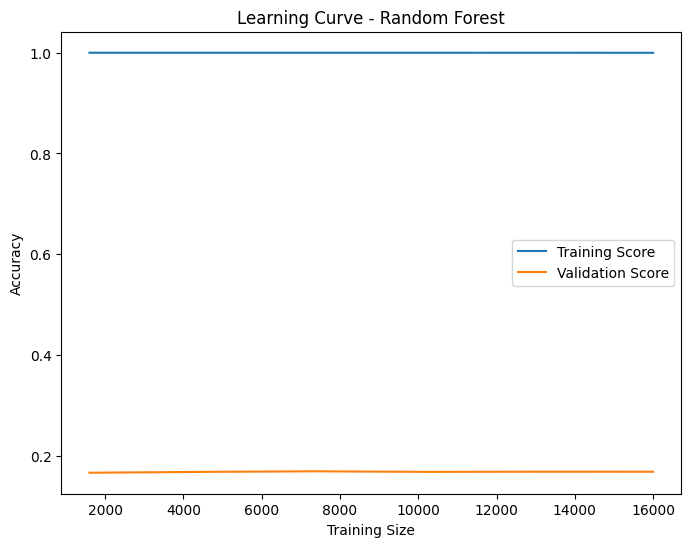

In [41]:
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt
import numpy as np

train_sizes, train_scores, val_scores = learning_curve(
    rf,
    X,
    y,
    cv=5,
    train_sizes=np.linspace(0.1, 1.0, 6),
    scoring="accuracy",
    n_jobs=-1
)

plt.figure(figsize=(8,6))
plt.plot(train_sizes, np.mean(train_scores, axis=1), label="Training Score")
plt.plot(train_sizes, np.mean(val_scores, axis=1), label="Validation Score")
plt.xlabel("Training Size")
plt.ylabel("Accuracy")
plt.title("Learning Curve - Random Forest")
plt.legend()
plt.show()

             Feature  Importance
6           rainfall    0.120387
3        temperature    0.119816
5                 ph    0.119288
4           humidity    0.118963
2          potassium    0.117596
1         phosphorus    0.116335
0           nitrogen    0.115837
7     nutrient_index    0.113271
9    soil_type_Peaty    0.012085
8    soil_type_Loamy    0.011878
10  soil_type_Saline    0.011865
12    soil_type_Silt    0.011799
11   soil_type_Sandy    0.010881


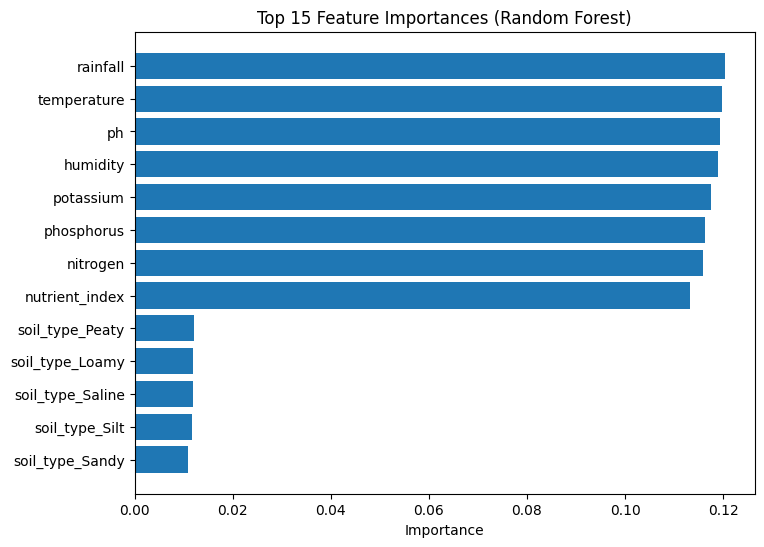

In [42]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importances = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf.feature_importances_
}).sort_values(by="Importance", ascending=False)

print(feature_importances.head(15))

plt.figure(figsize=(8,6))
plt.barh(
    feature_importances["Feature"].head(15)[::-1],
    feature_importances["Importance"].head(15)[::-1]
)
plt.xlabel("Importance")
plt.title("Top 15 Feature Importances (Random Forest)")
plt.show()